# A Jupyter Notebook that plots all the graphs for the paper 

### Sensitivity Test for Lambda

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Take the last three rounds to get the mean and std
lambdas = np.array([0.001, 0.01, 0.1, 2, 4, 5, 9, 13, 20])
accs = np.array([0.9431, 0.9868, 0.9559, 0.0234, 0.0353, 0.0326, 0.0469, 0.06, 0.0152])  # global poisoning accuracy
accs = np.array([
    [0.95, 0.9481, 0.9431],
    [0.9876, 0.9893, 0.9868],
    [0.9236, 0.9306, 0.9559],
    [0.0221, 0.0186, 0.0234],
    [0.0262, 0.0348, 0.0353],
    [0.0326, 0.0296, 0.0326],
    [0.0528, 0.0573, 0.0469],
    [0.0578, 0.0372, 0.0463],
    [0.0164, 0.0107, 0.0152],
])

def simple_plot(lambdas, accs):
    # 1) Simple plot (log-x)
    plt.figure(figsize=(6,4))
    plt.plot(lambdas, accs, marker='o', linestyle='-')
    plt.xscale('log')
    plt.xlabel('lambda (log scale)')
    plt.ylabel('global poisoning accuracy')
    plt.title('Poisoning accuracy vs lambda')
    plt.grid(True, which='both', ls=':', alpha=0.6)
    plt.show()

# 2) Fit an exponential decay acc = a + b * exp(-c * lambda)
def exp_decay(x, a, b, c):
    return a + b * np.exp(-c * x)

def plot_expo_decay(lambdas, accs):
    gba_means = accs.mean(axis=1)
    gba_stds = accs.std(axis=1, ddof=1)

    p0 = [min(gba_means), max(gba_means)-min(gba_means), 1.0]  # initial guess
    try:
        popt, pcov = curve_fit(exp_decay, lambdas, gba_means, p0=p0, maxfev=10000)
        lambdas_dense = np.logspace(np.log10(lambdas.min()*0.5), np.log10(lambdas.max()*2), 200)
        fit_vals = exp_decay(lambdas_dense, *popt)
        plt.figure(figsize=(6,4), dpi=300)
        # plt.plot(lambdas, accs, 'o', label='data', color='#1f77b4', markersize=5)
        plt.errorbar(lambdas, gba_means,yerr=gba_stds,fmt='o',color='#1f77b4',capsize=4,label='data (mean ± std)')
        plt.plot(lambdas_dense, fit_vals, '-', label=f'fit: a={popt[0]:.3f}, b={popt[1]:.3f}, c={popt[2]:.3f}', color='#ff7f0e', linewidth=2.2)
        plt.xscale('log'); plt.xlabel('Lambda', fontsize=12, labelpad=2); plt.ylabel('Global Backdoor Accuracy (GBA)', fontsize=12, labelpad=2)
        plt.title(r'Sensitivity Test of GBA to Similarity Strictness ($\lambda$)')
        plt.legend(); plt.grid(True, which='both', ls=':')
        plt.show()
    except Exception as e:
        print("fit failed:", e)


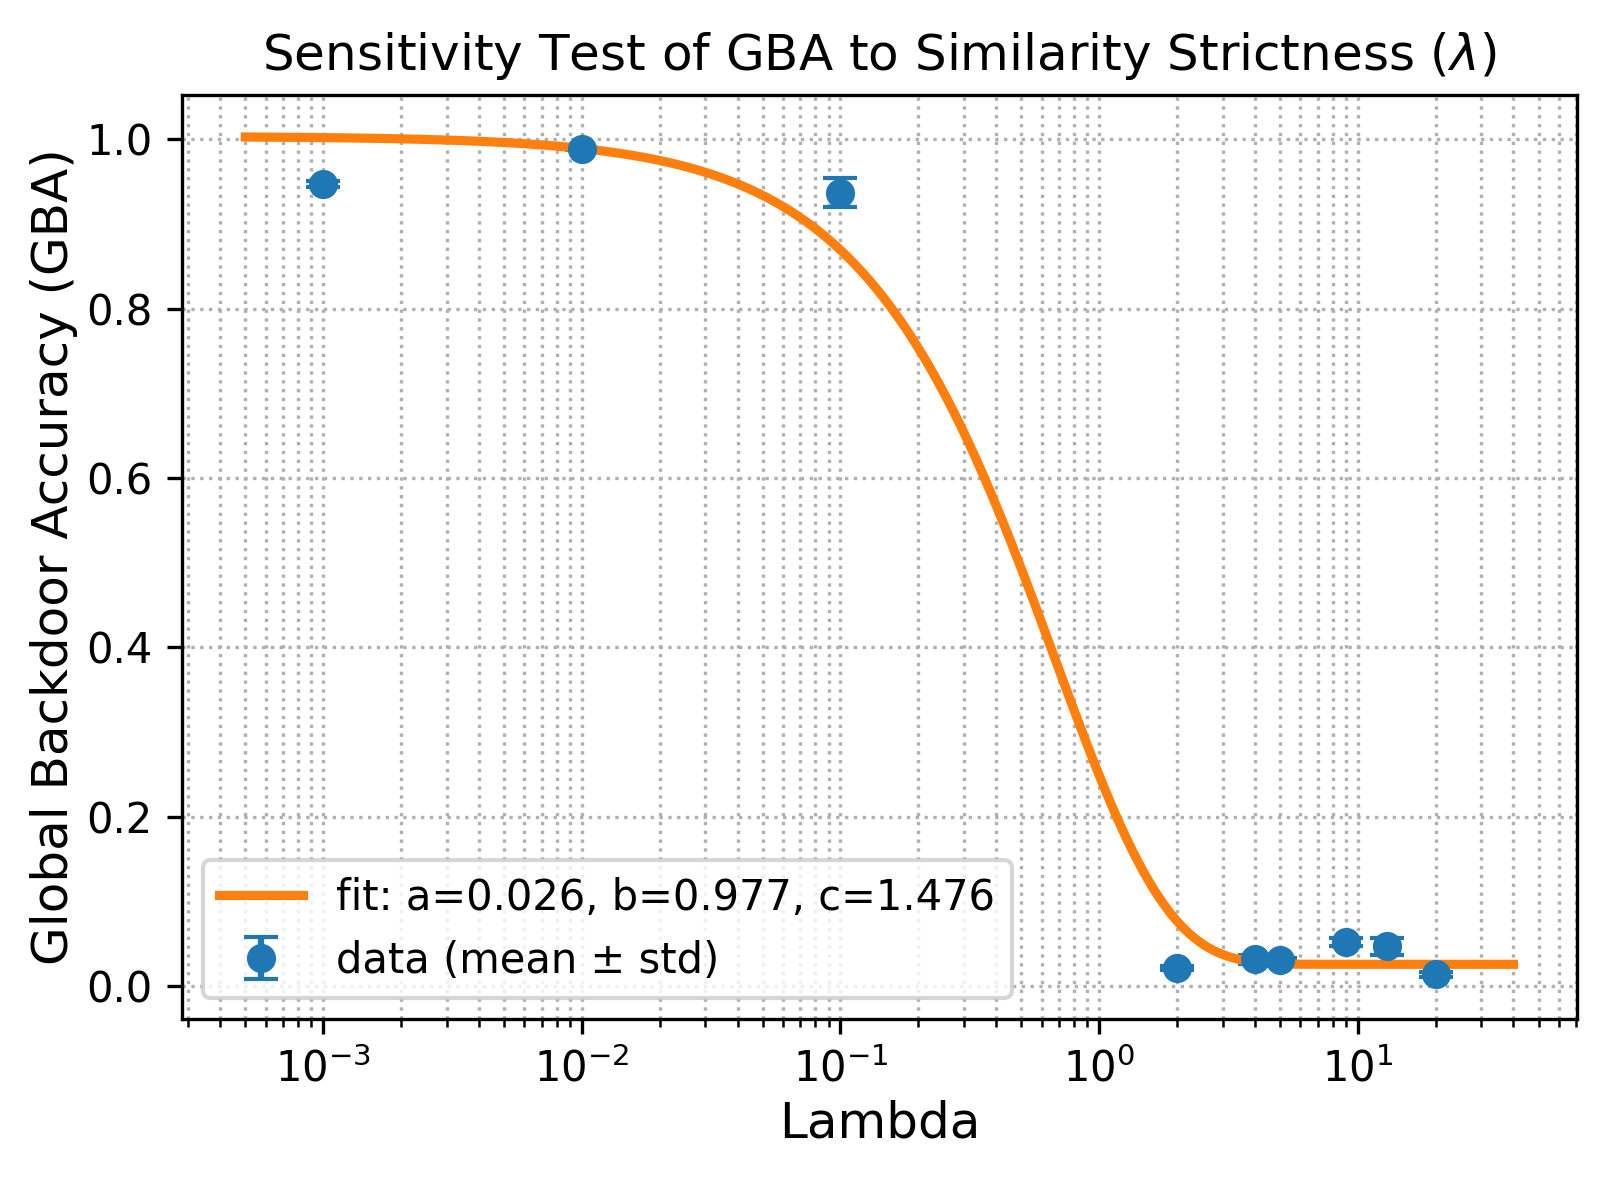

In [20]:
plot_expo_decay(lambdas, accs)

In [8]:
# # 3) Knee detection with curvature (simple numerical approach)
# from scipy.interpolate import UnivariateSpline
# # Interpolate on log-lambda and compute curvature of the spline
# logl = np.log10(lambdas)
# spline = UnivariateSpline(logl, accs, k=3, s=0.01)
# xs = np.linspace(logl.min(), logl.max(), 300)
# y = spline(xs)
# y1 = spline.derivative(1)(xs)
# y2 = spline.derivative(2)(xs)
# curvature = np.abs(y2) / (1 + y1**2)**1.5
# knee_idx = np.argmax(curvature)
# knee_lambda = 10**xs[knee_idx]
# print("Estimated knee at lambda ≈", knee_lambda)

# plt.figure(figsize=(6,4))
# plt.plot(10**xs, y, '-', label='spline (interp)')
# plt.plot(lambdas, accs, 'o')
# plt.scatter([knee_lambda], [spline(xs[knee_idx])], color='red', zorder=10, label='knee')
# plt.xscale('log')
# plt.xlabel('lambda'); plt.ylabel('poisoning acc')
# plt.legend(); plt.grid(True, which='both', ls=':')
# plt.show()

# # 4) Simple sensitivity metrics
# # finite-difference derivative on log-lambda
# log_l = np.log10(lambdas)
# dacc_dlogl = np.gradient(accs, log_l)  # d(acc)/d(log10 lambda)
# for L, deriv in zip(lambdas, dacc_dlogl):
#     print(f"lambda={L:>6}: d(acc)/d(log10 lambda) = {deriv:.4f}")